# 01 - Exploratory Data Analysis

This notebook explores the raw OHLCV financial time-series data across three asset classes:
- **Crypto:** BTC/USDT, ETH/USDT, BNB/USDT, ADA/USDT
- **Forex:** EUR/USD, USD/JPY, GBP/USD, AUD/USD
- **Indices:** USA30, USA500, USATECH, DEUIDX

We examine data distributions, temporal patterns, stationarity, and correlations.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.data.loader import load_raw_csv, list_available_assets
from src.data.preprocessing import get_data_summary
from src.utils.config import ProjectConfig

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

config = ProjectConfig('..')
print('Available assets:', list_available_assets(config.get_path('data_raw')))

Available assets: ['ADAUSDT_H1.csv', 'AUDUSD_H1.csv', 'BNBUSDT_H1.csv', 'BTCUSDT_H1.csv', 'DEUIDXEUR_H1.csv', 'ETHUSDT_H1.csv', 'EURUSD_H1.csv', 'GBPUSD_H1.csv', 'USA30IDXUSD_H1.csv', 'USA500IDXUSD_H1.csv', 'USATECHIDXUSD_H1.csv', 'USDJPY_H1.csv']


## 1. Load All Datasets

In [2]:
# Load all assets grouped by category
datasets = {}
for category in config.get_categories():
    assets = config.get_assets_for_category(category)
    for asset in assets:
        path = config.get_path('data_raw') / asset['file']
        df = load_raw_csv(path)
        datasets[(category, asset['name'])] = df
        print(f"{category}/{asset['name']}: {len(df)} rows, "
              f"{df.index.min()} to {df.index.max()}")

2026-02-23 17:31:30,668 - src.data.loader - INFO - Loading CSV: ..\data\raw\BTCUSDT_H1.csv
2026-02-23 17:31:30,961 - src.data.loader - INFO - Loaded 74289 rows from BTCUSDT_H1.csv
crypto/BTCUSDT: 74289 rows, 2017-08-17 04:00:00 to 2026-02-12 01:00:00
2026-02-23 17:31:30,968 - src.data.loader - INFO - Loading CSV: ..\data\raw\ETHUSDT_H1.csv
2026-02-23 17:31:31,159 - src.data.loader - INFO - Loaded 74289 rows from ETHUSDT_H1.csv
crypto/ETHUSDT: 74289 rows, 2017-08-17 04:00:00 to 2026-02-12 01:00:00
2026-02-23 17:31:31,162 - src.data.loader - INFO - Loading CSV: ..\data\raw\BNBUSDT_H1.csv
2026-02-23 17:31:31,357 - src.data.loader - INFO - Loaded 72334 rows from BNBUSDT_H1.csv
crypto/BNBUSDT: 72334 rows, 2017-11-06 03:00:00 to 2026-02-12 01:00:00
2026-02-23 17:31:31,360 - src.data.loader - INFO - Loading CSV: ..\data\raw\ADAUSDT_H1.csv
2026-02-23 17:31:31,540 - src.data.loader - INFO - Loaded 68359 rows from ADAUSDT_H1.csv
crypto/ADAUSDT: 68359 rows, 2018-04-17 04:00:00 to 2026-02-12 01:00

## 2. Data Summary Statistics

In [3]:
# Summary statistics for each asset
summaries = []
for (category, asset_name), df in datasets.items():
    summary = get_data_summary(df)
    row = {
        'category': category,
        'asset': asset_name,
        'n_rows': summary['n_rows'],
        'start': summary['date_range']['start'],
        'end': summary['date_range']['end'],
        'close_mean': summary['statistics']['close']['mean'],
        'close_std': summary['statistics']['close']['std'],
        'volume_mean': summary['statistics']['volume']['mean'],
        'missing': sum(summary['missing_values'].values()),
    }
    summaries.append(row)

summary_df = pd.DataFrame(summaries)
summary_df

,category,asset,n_rows,start,end,close_mean,close_std,volume_mean,missing
0,crypto,BTCUSDT,74289,2017-08-17 04:00:00,2026-02-12 01:00:00,36629.869262,32413.257564,1.745430e+03,0
1,crypto,ETHUSDT,74289,2017-08-17 04:00:00,2026-02-12 01:00:00,1662.906796,1297.732217,1.509454e+04,0
2,crypto,BNBUSDT,72334,2017-11-06 03:00:00,2026-02-12 01:00:00,294.482053,281.227084,5.485517e+04,0
3,crypto,ADAUSDT,68359,2018-04-17 04:00:00,2026-02-12 01:00:00,0.511998,0.520653,6.706813e+06,0
4,forex,EURUSD,100000,2010-01-29 14:00:00,2026-02-12 00:00:00,1.185083,0.110715,9.971150e+03,0
5,forex,USDJPY,100000,2010-01-28 05:00:00,2026-02-12 00:00:00,113.007556,21.953997,9.014597e+03,0
6,forex,GBPUSD,100000,2010-01-28 16:00:00,2026-02-12 00:00:00,1.402878,0.147747,6.780756e+03,0
7,forex,AUDUSD,100000,2010-01-26 21:00:00,2026-02-12 00:00:00,0.790616,0.133257,5.392563e+03,0
8,indices,USA30IDXUSD,68377,2013-05-23 00:00:00,2026-02-12 00:00:00,28535.660606,9214.232959,5.717714e+01,0
9,indices,USA500IDXUSD,67322,2013-05-23 00:00:00,2026-02-12 00:00:00,3538.084452,1419.393024,5.493850e+01,0


## 3. Close Price Visualization

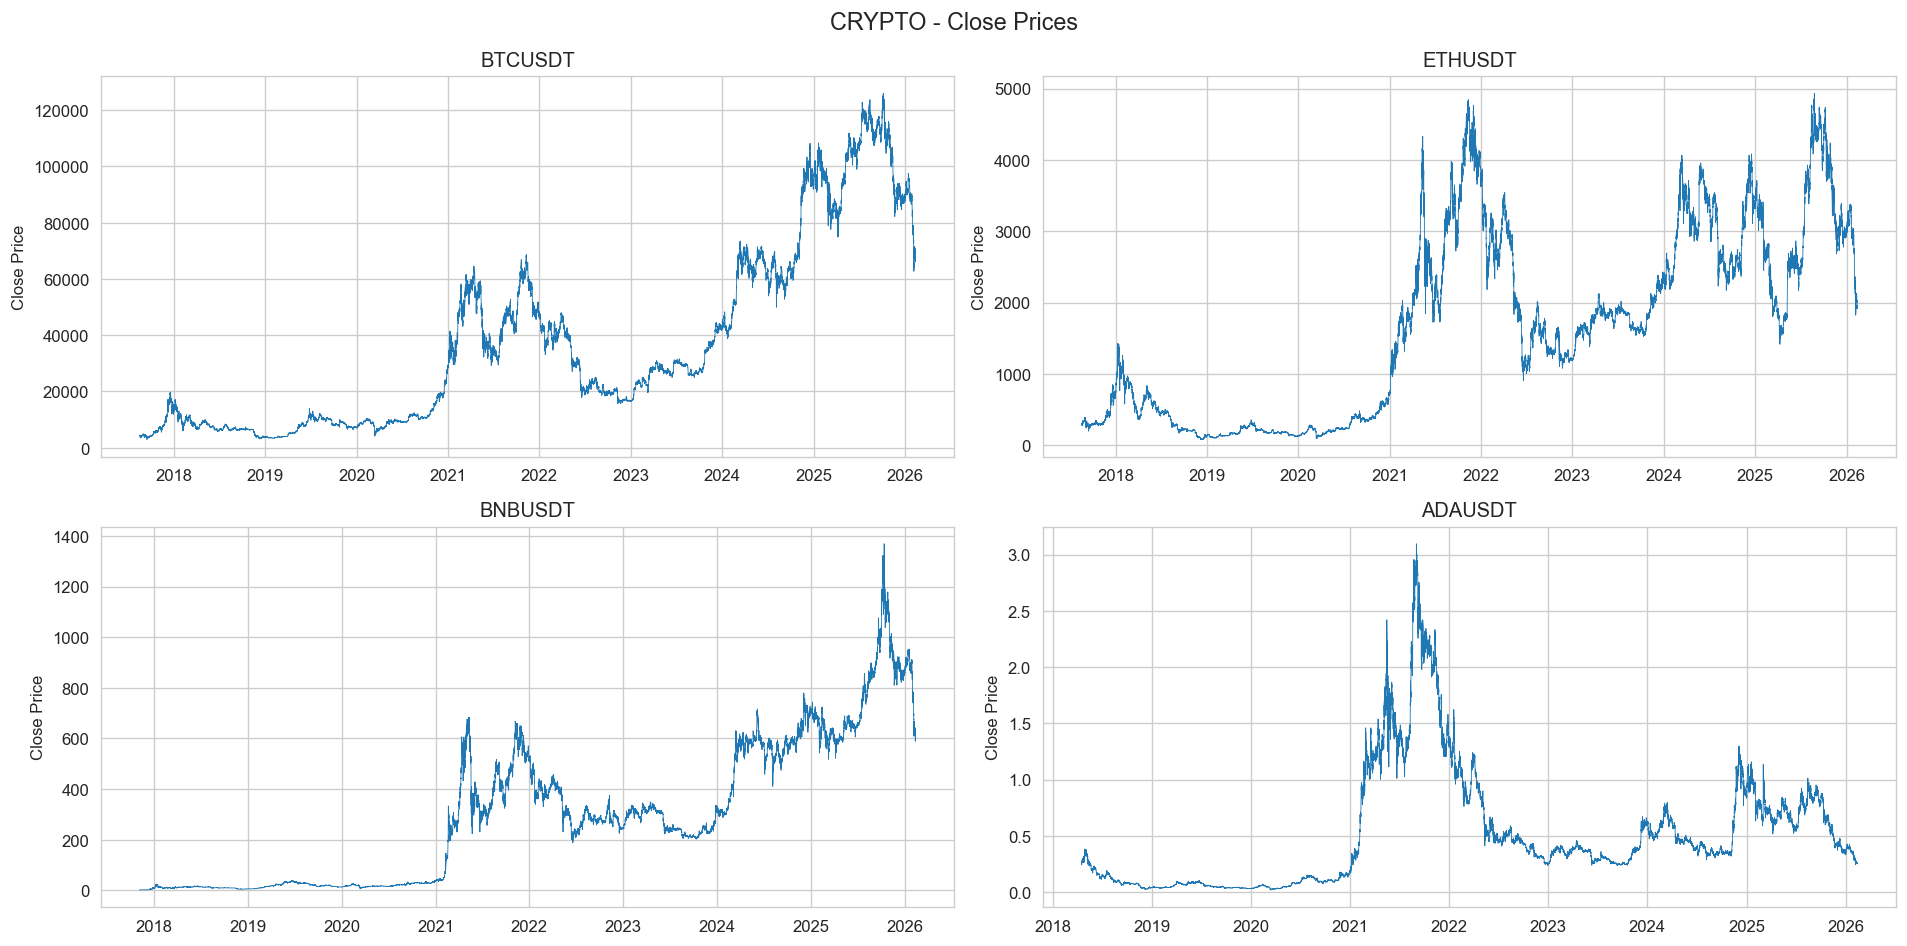

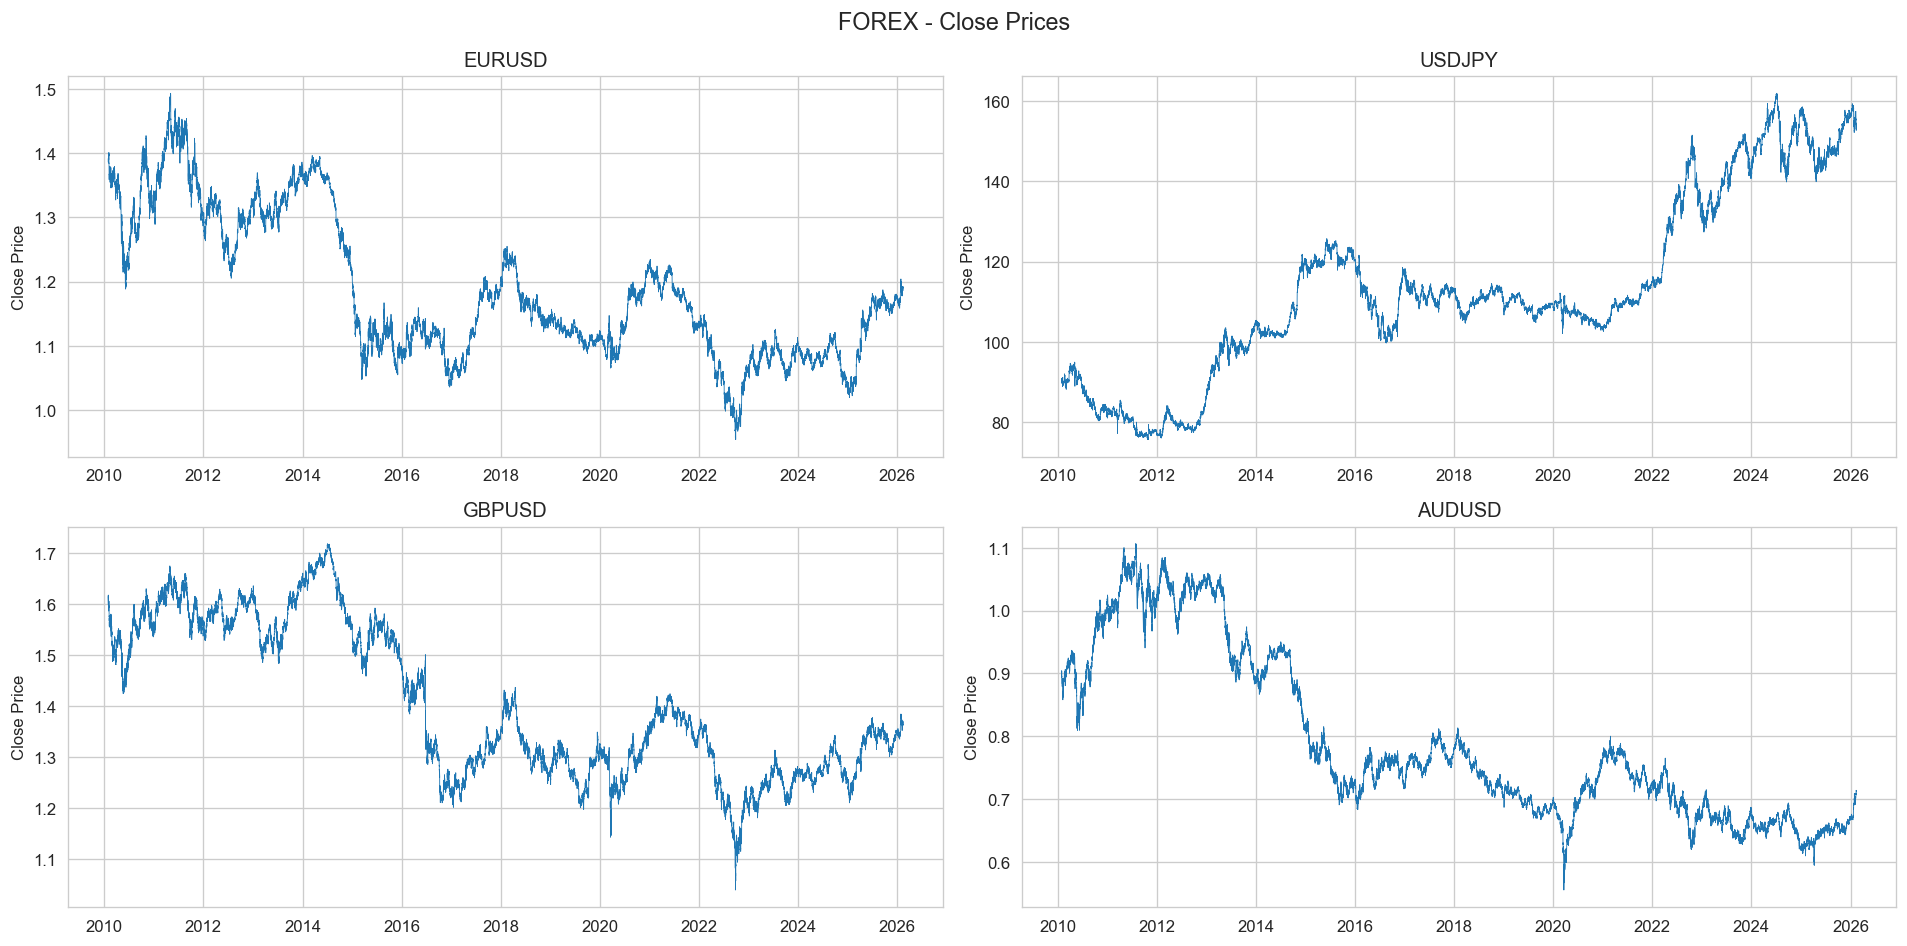

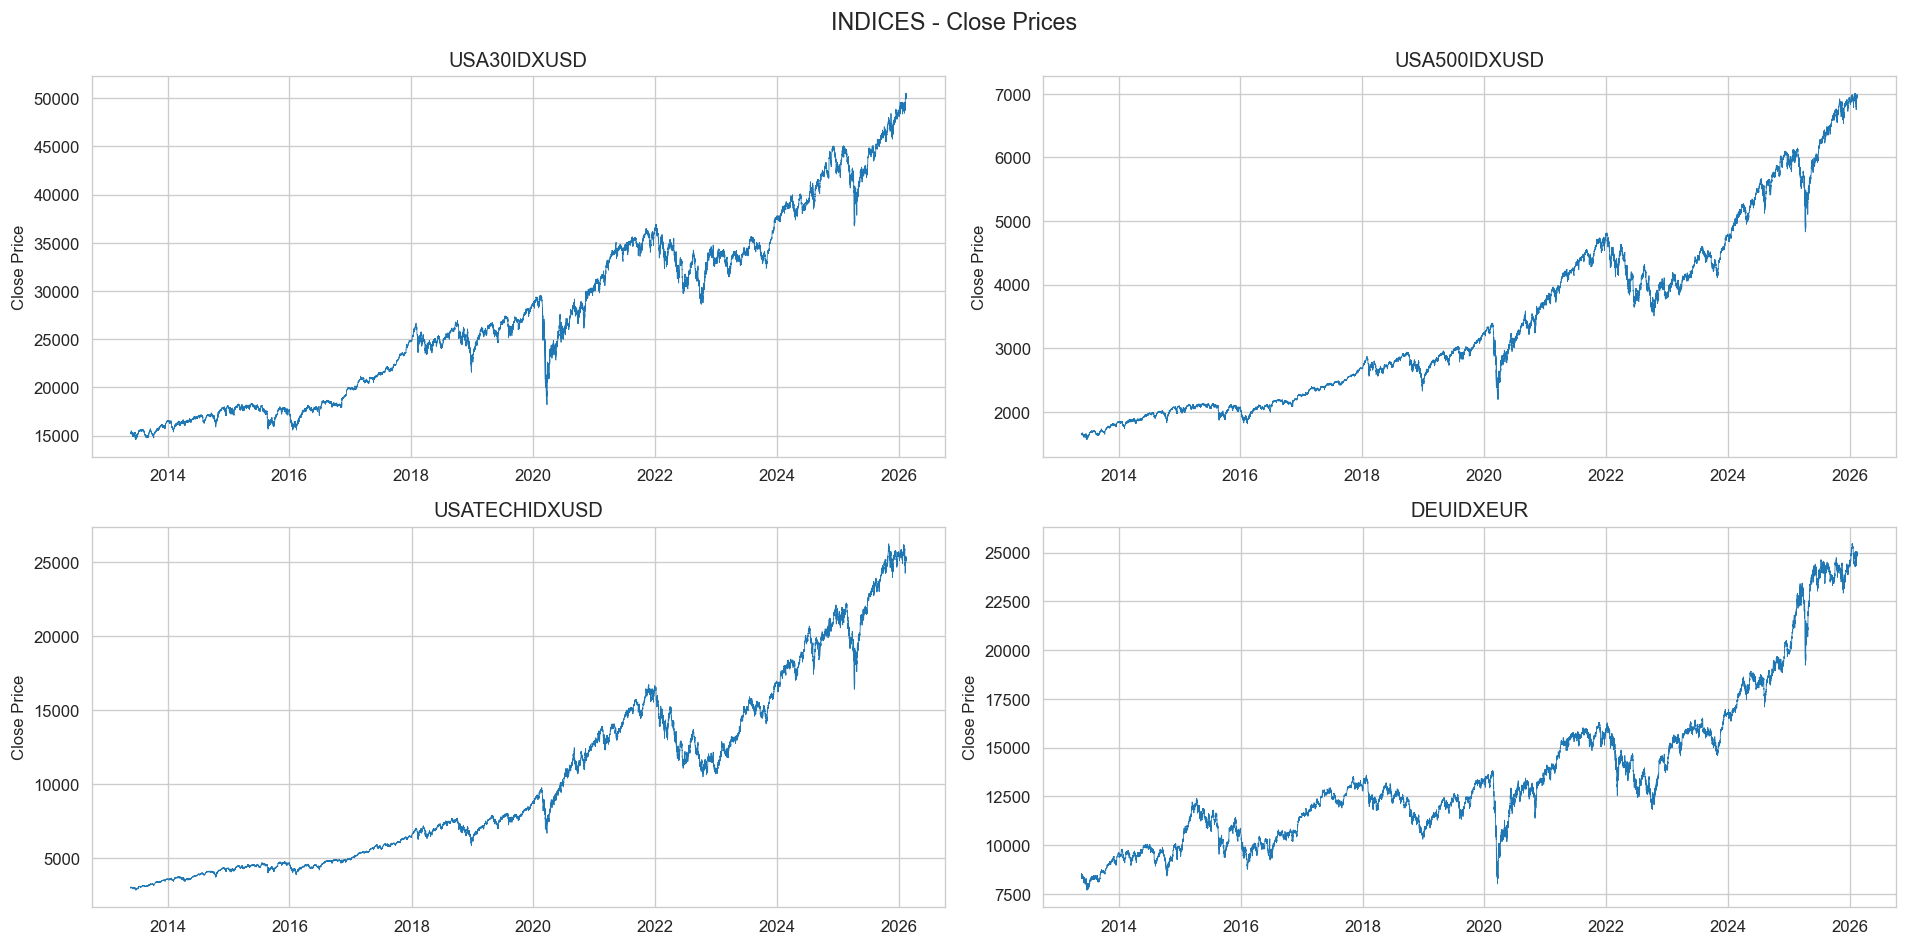

In [4]:
# Plot close prices by category
for category in config.get_categories():
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    fig.suptitle(f'{category.upper()} - Close Prices', fontsize=14)
    
    cat_assets = [(k, v) for k, v in datasets.items() if k[0] == category]
    for ax, ((cat, name), df) in zip(axes.flat, cat_assets):
        ax.plot(df.index, df['close'], linewidth=0.5)
        ax.set_title(name)
        ax.set_ylabel('Close Price')
    
    plt.tight_layout()
    plt.show()

## 4. Return Distributions

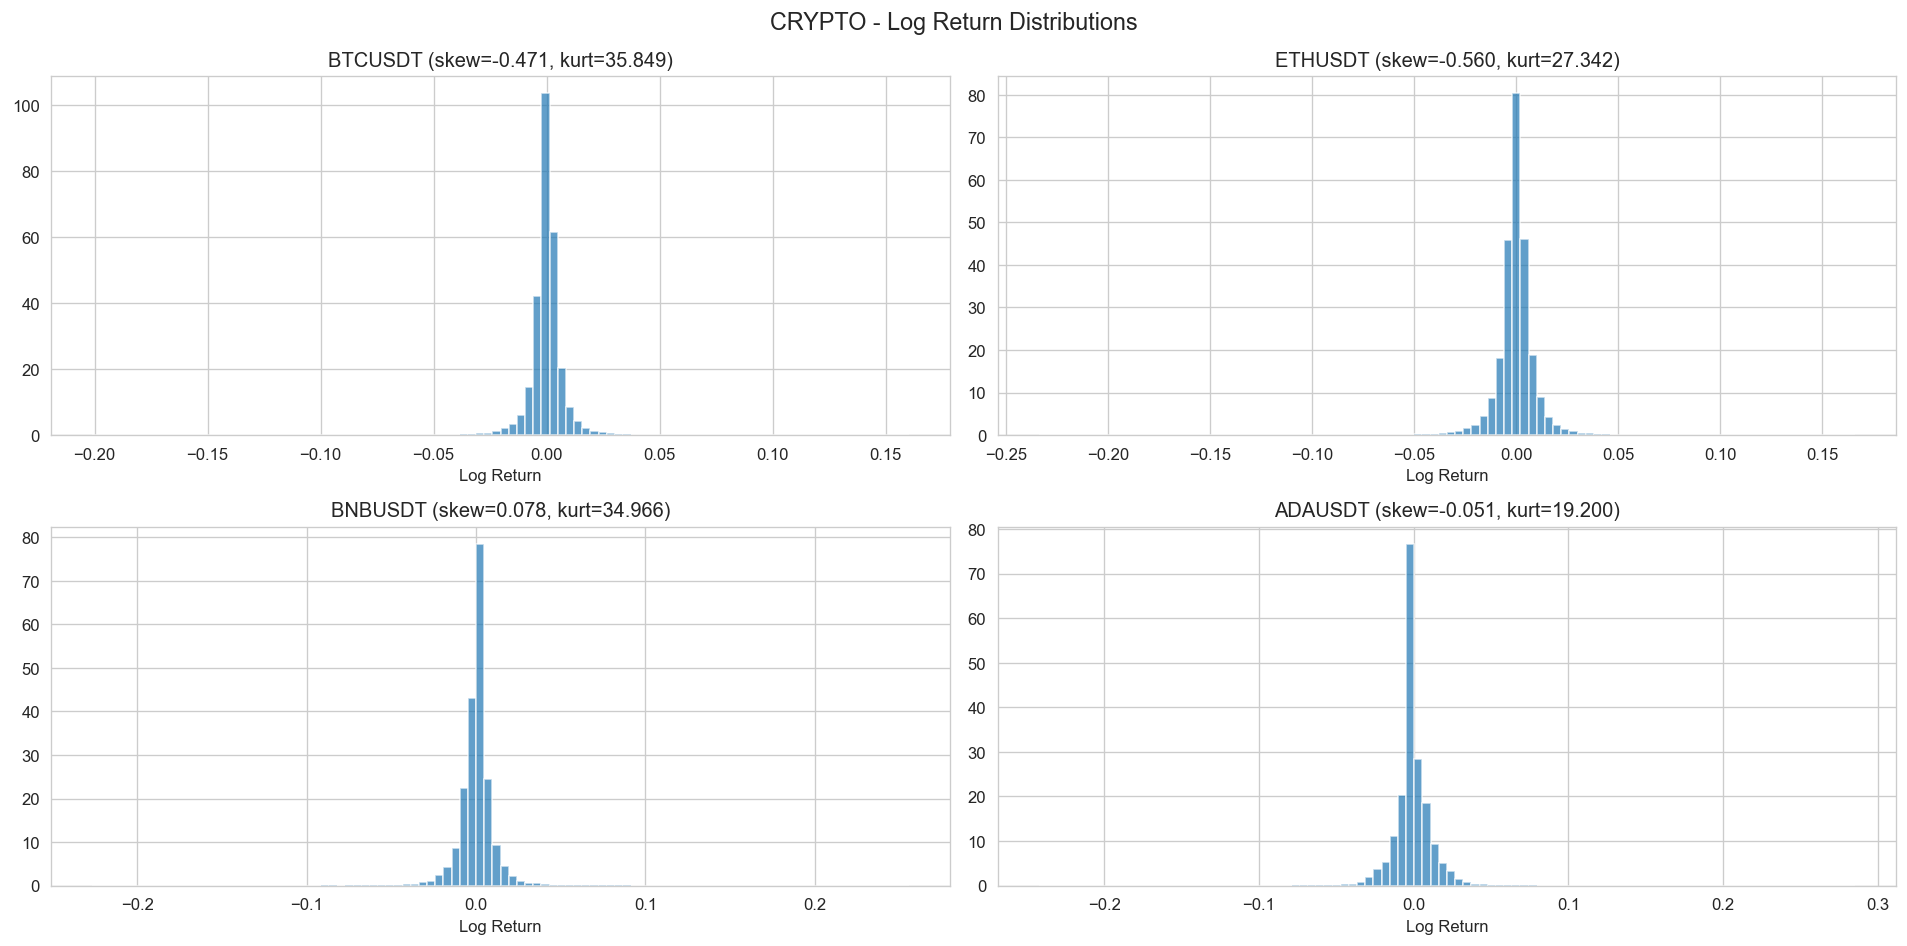

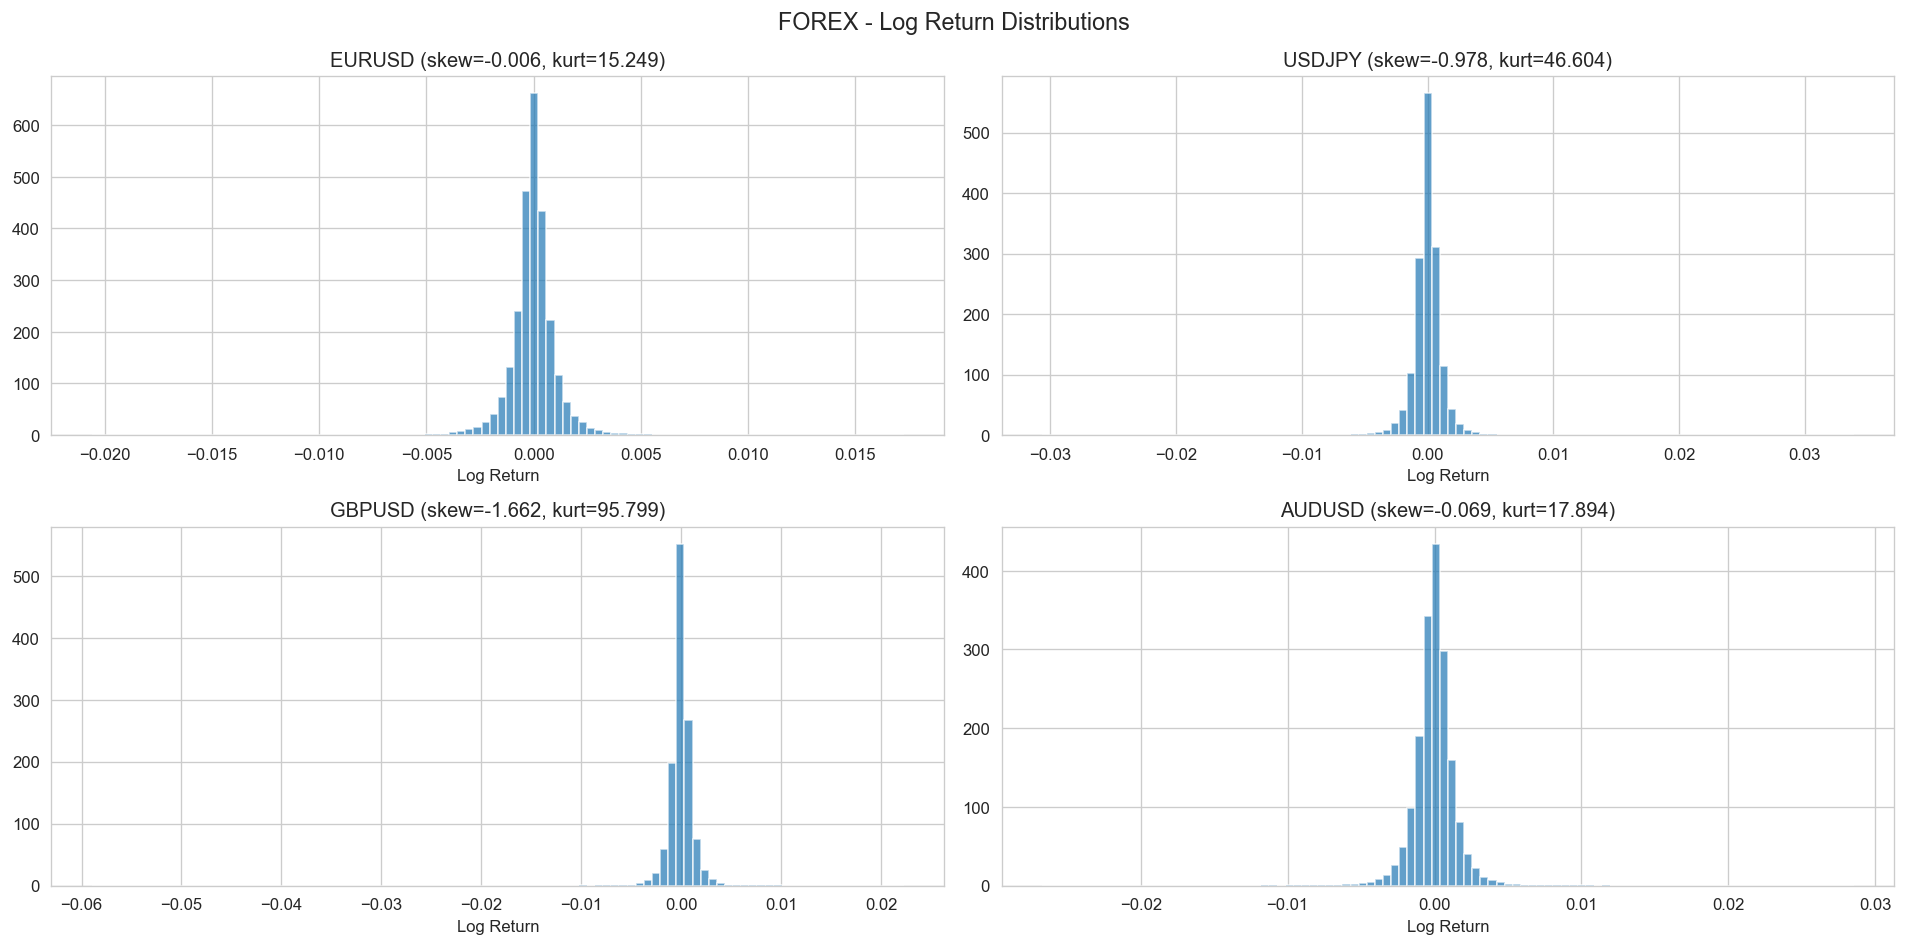

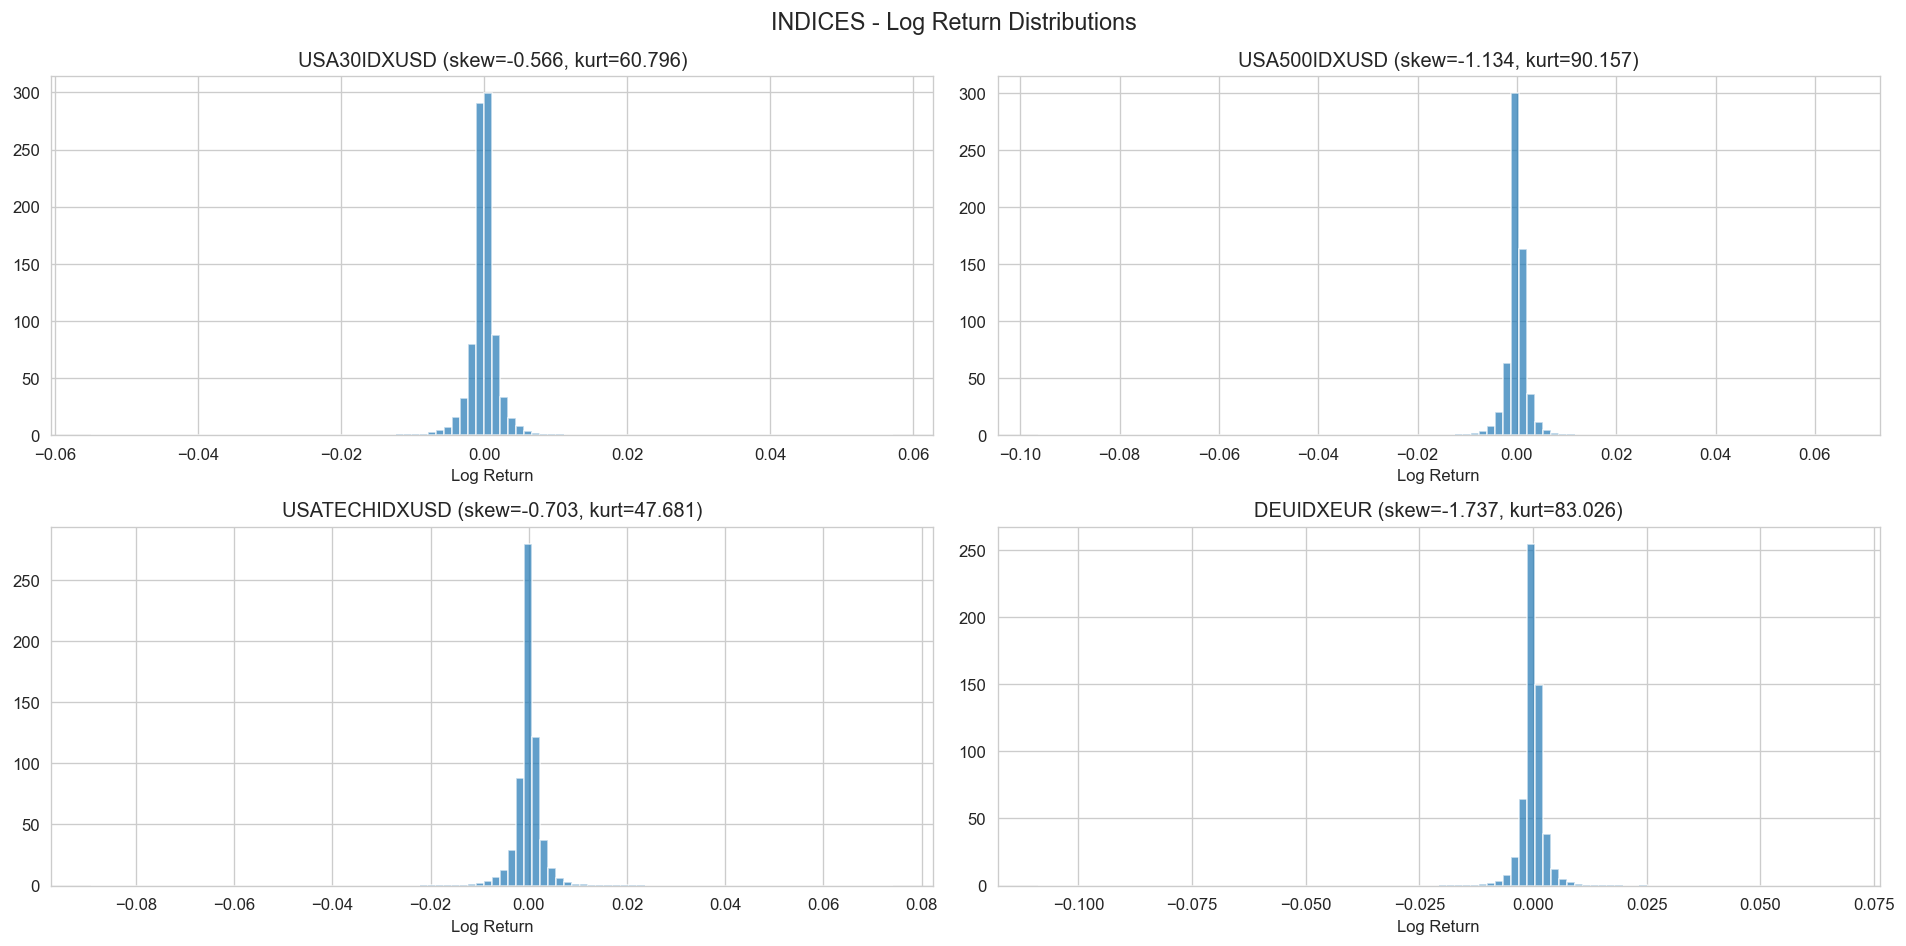

In [5]:
# Compute log returns and plot distributions
for category in config.get_categories():
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    fig.suptitle(f'{category.upper()} - Log Return Distributions', fontsize=14)
    
    cat_assets = [(k, v) for k, v in datasets.items() if k[0] == category]
    for ax, ((cat, name), df) in zip(axes.flat, cat_assets):
        returns = np.log(df['close'] / df['close'].shift(1)).dropna()
        ax.hist(returns, bins=100, density=True, alpha=0.7)
        ax.set_title(f'{name} (skew={returns.skew():.3f}, kurt={returns.kurtosis():.3f})')
        ax.set_xlabel('Log Return')
    
    plt.tight_layout()
    plt.show()

## 5. Volume Analysis

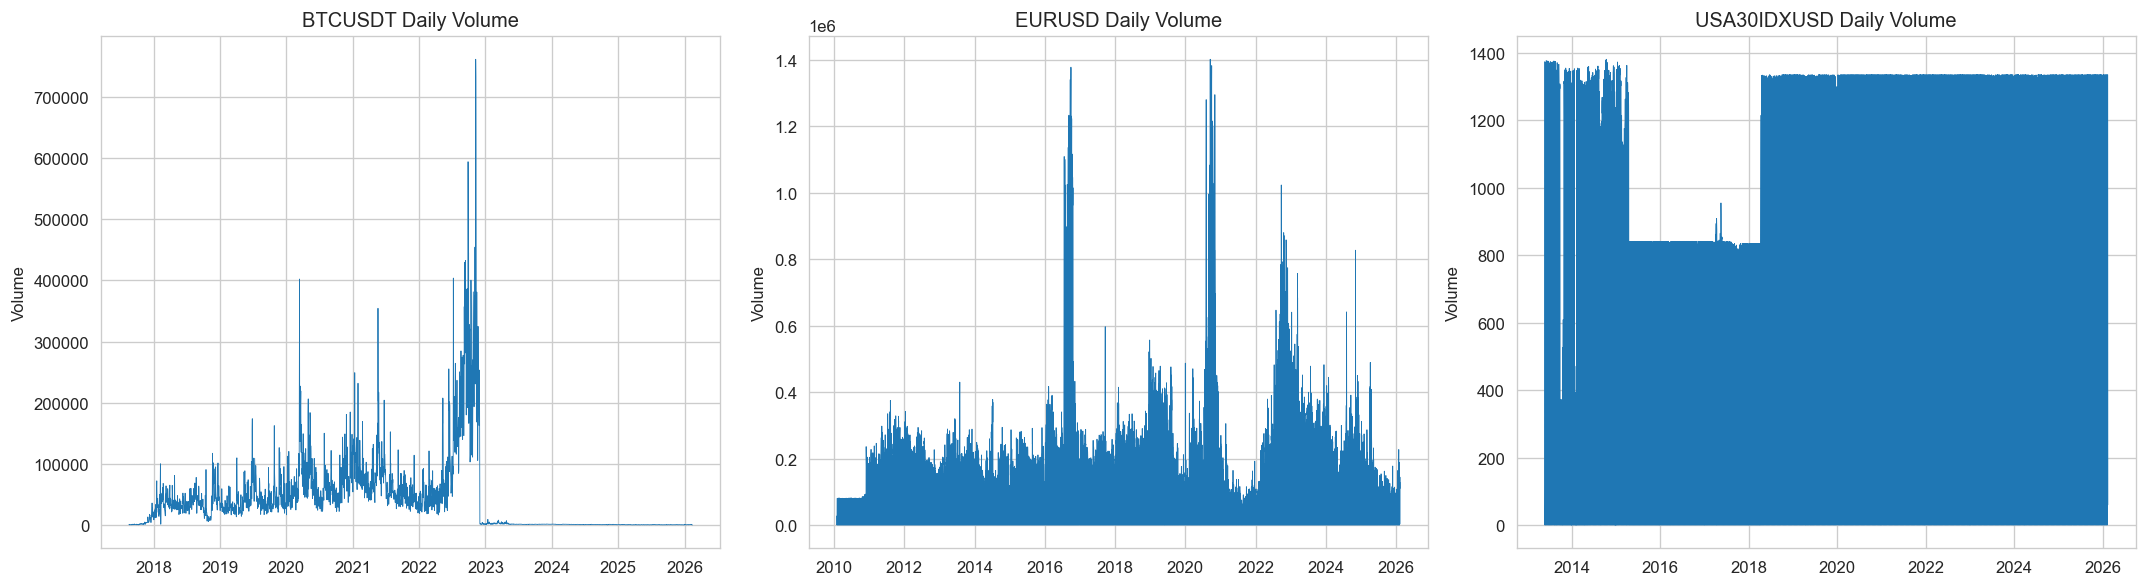

In [6]:
# Volume over time for representative assets
representatives = {
    cat: config.get_representative_asset(cat)
    for cat in config.get_categories()
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (cat, rep) in zip(axes, representatives.items()):
    df = datasets[(cat, rep)]
    # Resample to daily for cleaner visualization
    daily_vol = df['volume'].resample('D').sum()
    ax.plot(daily_vol.index, daily_vol.values, linewidth=0.5)
    ax.set_title(f'{rep} Daily Volume')
    ax.set_ylabel('Volume')

plt.tight_layout()
plt.show()

## 6. Feature Correlation Heatmaps

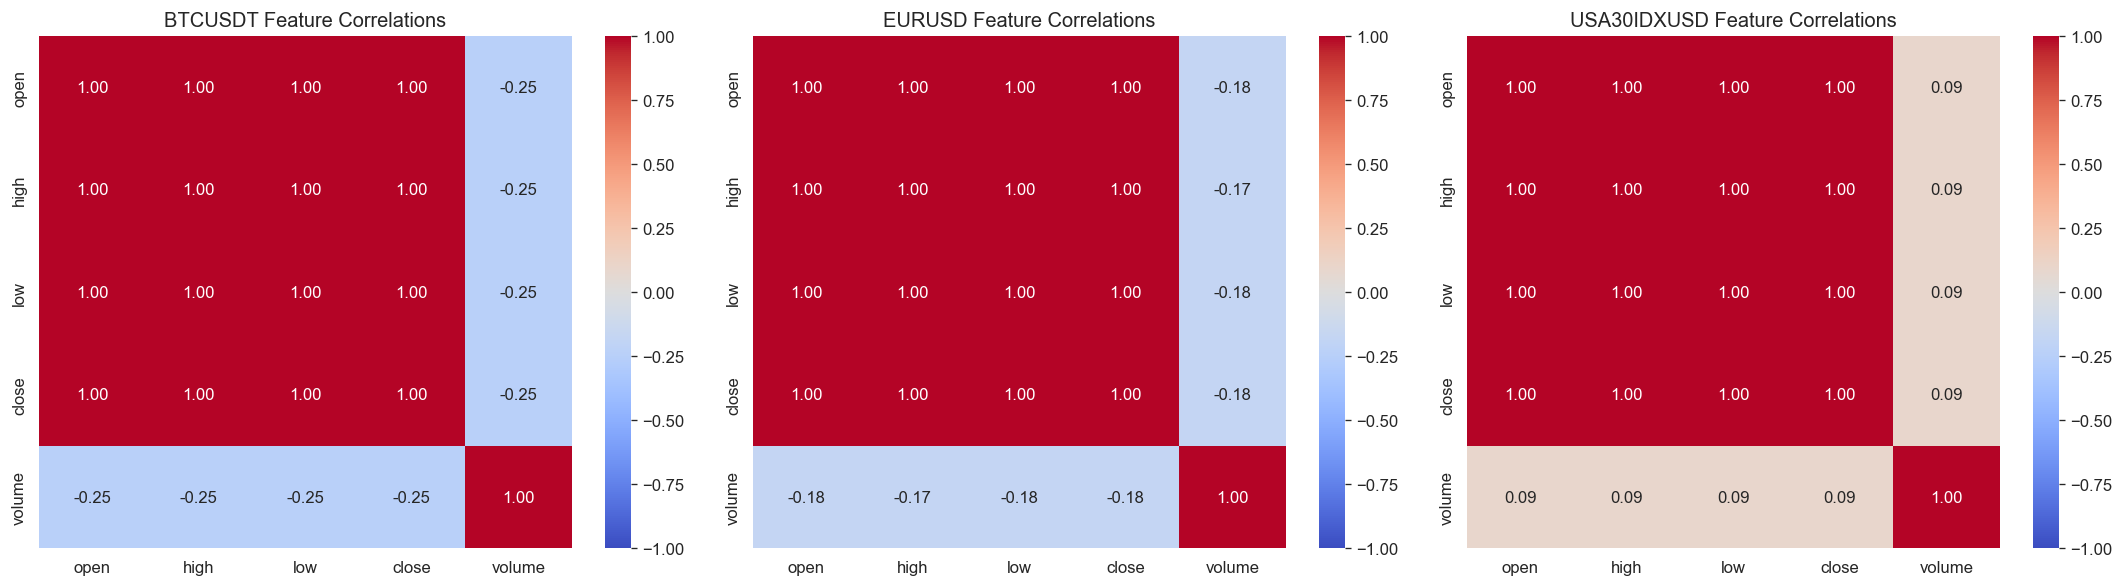

In [7]:
# Correlation heatmaps for representative assets
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (cat, rep) in zip(axes, representatives.items()):
    df = datasets[(cat, rep)]
    corr = df[['open', 'high', 'low', 'close', 'volume']].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
                vmin=-1, vmax=1, center=0)
    ax.set_title(f'{rep} Feature Correlations')

plt.tight_layout()
plt.show()

## 7. Volatility Comparison

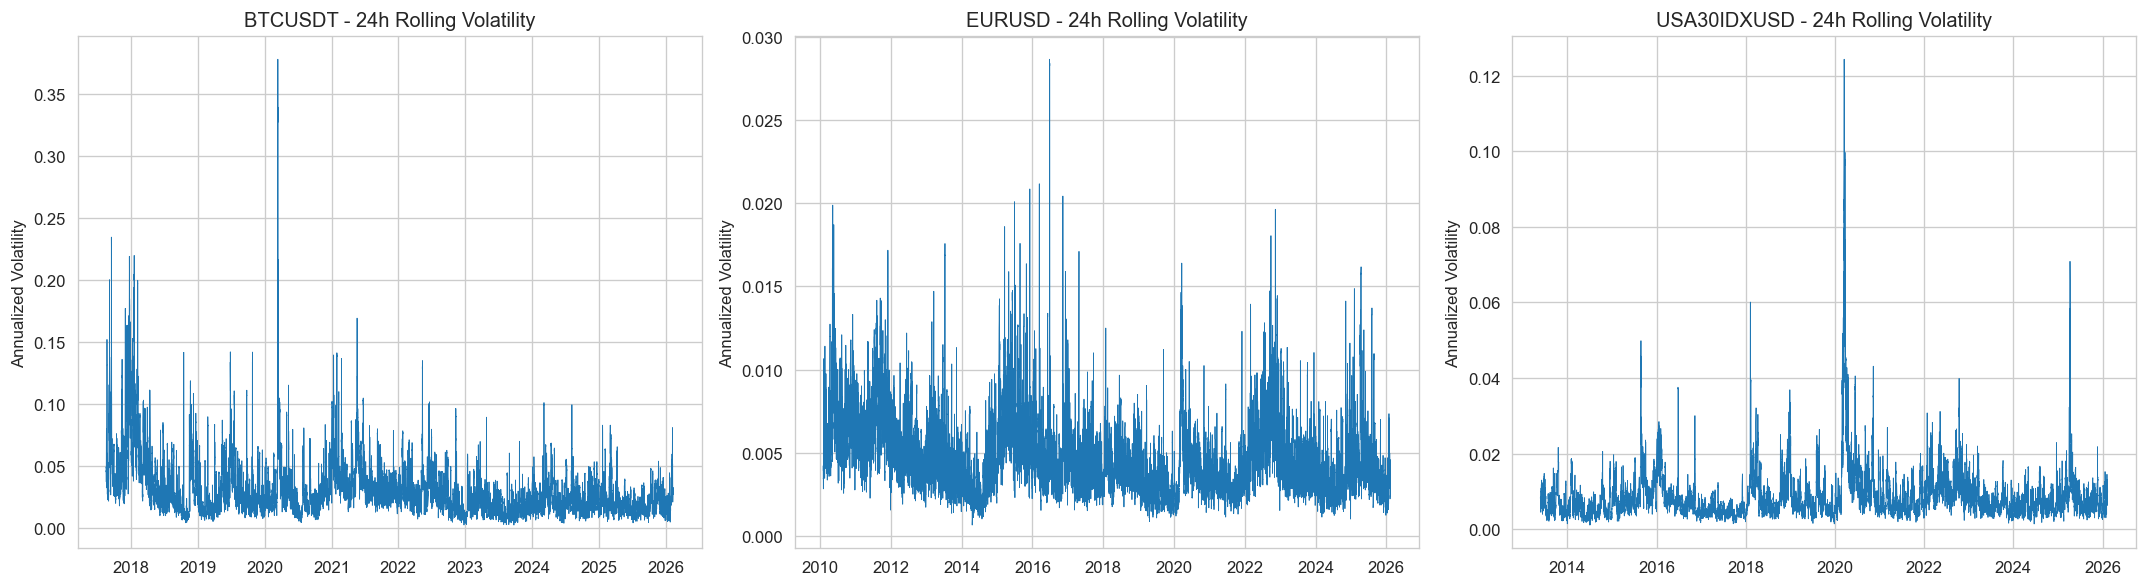


EDA complete. Proceed to 02_dataset_creation.ipynb for data preparation.


In [8]:
# Rolling volatility (24h = 24 data points for H1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (cat, rep) in zip(axes, representatives.items()):
    df = datasets[(cat, rep)]
    returns = np.log(df['close'] / df['close'].shift(1))
    rolling_vol = returns.rolling(window=24).std() * np.sqrt(24)
    ax.plot(rolling_vol.index, rolling_vol.values, linewidth=0.5)
    ax.set_title(f'{rep} - 24h Rolling Volatility')
    ax.set_ylabel('Annualized Volatility')

plt.tight_layout()
plt.show()

print('\nEDA complete. Proceed to 02_dataset_creation.ipynb for data preparation.')